# Logistic Regression:

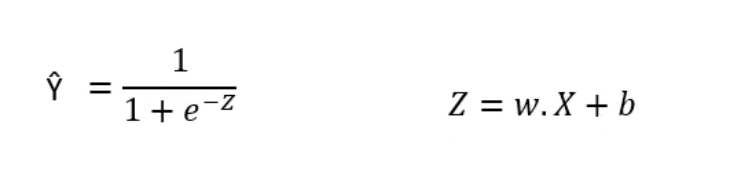


Y_hat -- > predicted value

X -> Independent Variable

w -> weight

b -> bias

# Gradient Descent:

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for
updating the parameters of the learning model.

W=w-a*dw

b = b - a*db

# Learning Rate (a):

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum
of a loss function.

# Derivatives:

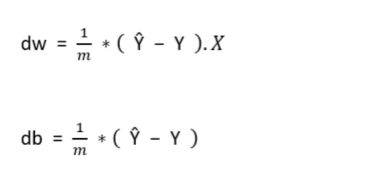



# work flow

Work flow of the Logistic Regression model:

Step 1: Set Learning Rate & Number of Iterations; Initiate Random weight and bias value.

Step 2: Build Logistic Regression Function. (sigmoid function)

Step 3: Update the parameters using gradient descent

Finally we will get the best model (best weight and bias value) as it has minimum cost function.

estep 4: build the "predict" function to determine the class of the data point.


In [ ]:
# importing numpy library
import numpy as np

# Logistic Regression

In [ ]:
class Logistic_Regression():

# declaring learning rate and no of iterations
  def __init__(self ,learning_rate , no_of_iterations ):
    self.no_of_iterations = no_of_iterations
    self.learning_rate = learning_rate



# fit function to train the model with dataset
  def fit(self, X , Y):

    # number of datapoints in the dataset (number of rows) --> m
    # number of input features in the dataset (number of columns) -->
    self.m , self.n = X.shape


# initiating weight and bias Value
    self.w = np.zeros(self.n)
    self.b = 0
    self.X = X
    self.Y = Y

# implementhing Gradient Desecent for Optimiza tion
    for i in range(self.no_of_iterations):
      self.update_weights()

  def update_weights(self ,):

    # Y_cap formula(sigmoid function)

    Y_cap = 1 / (1 + np.exp(-(self.X.dot(self.w) + self.b)))

    # derivative (gradients)
    dw = (1 / self.m) * np.dot(self.X.T , (Y_cap - self.Y))
    db = (1 / self.m) * np.sum(Y_cap - self.Y)

# Updateing the weights and bias using gradient descent
    self.w = self.w - self.learning_rate * dw
    self.b = self.b - self.learning_rate * db
# Sigmoide equation and diciision bound
  def predict(self ,X):
    Y_pred = 1 / (1 + np.exp(-(X.dot(self.w) + self.b)))
    Y_pred = np.where(Y_pred > 0.5 , 1 , 0)  # Y_pred > 0.5 , 1 , 0 --> if value of Y_pred > 0.5 then Y_pred = 1 else Y_pred = 0
    return Y_pred

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
data = pd.read_csv('diabetes.csv')

In [ ]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
data.shape

(768, 9)

In [ ]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
data['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


0 --> Non diabetic
1 --> diabetic

In [ ]:
data.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [ ]:
feature = data.drop(columns=['Outcome'] , axis=1)
target = data['Outcome']

In [ ]:
print(feature)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [ ]:
print(target)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Data Standardization

In [ ]:
scalar = StandardScaler()

In [ ]:
scalar.fit(feature)

StandardScaler()

In [ ]:
standerdized_data = scalar.transform(feature)

In [ ]:
print(standerdized_data)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [ ]:
feature = standerdized_data
target = data['Outcome']

In [ ]:
print(feature)
print(target)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]
0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [ ]:
X_train , X_test , Y_train , Y_test = train_test_split(feature , target , test_size=0.2 , random_state=2)


In [ ]:
print( feature.shape ,  X_test.shape , Y_train.shape)

(768, 8) (154, 8) (614,)


# Training Our Model

In [ ]:
classifier = Logistic_Regression(learning_rate=0.01 , no_of_iterations=1000)

In [ ]:
classifier.fit(X_train , Y_train)

# Evaluating Our Model

In [ ]:
# Accuracy score on training data
X_train_prediction = classifier.predict(X_train)
test_data_accuracy = accuracy_score(Y_train , X_train_prediction)
print('Accuracy score of the training data : ' , test_data_accuracy)

Accuracy score of the training data :  0.7768729641693811


In [ ]:
# Accuracu score on test data
X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(Y_test , X_test_prediction)
print('Accuracy score of the test data : ' , test_data_accuracy)

Accuracy score of the test data :  0.7662337662337663


# Making a Predictive System


In [ ]:
input_data = (5,166,72,19,175,25.8,0.587,51)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicling for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# standardize the input data
std_data = scalar.transform(input_data_reshaped)
print(std_data)

prediction = classifier.predict(std_data)
print(prediction)

if (prediction[0] == 0):
   print('The person is not diabetic')
else:
   print('The person is diabetic')

[[ 0.3429808   1.41167241  0.14964075 -0.09637905  0.82661621 -0.78595734
   0.34768723  1.51108316]]
[1]
The person is diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
